# **Modul 02 Linear regression**
Comment ditambahkan pada markdown

In [25]:
# Dependencies
# Memuat library yang dibutuhkan dalam pemrosesan data dan pembuatan
# model regresi linier
import numpy as np
import matplotlib.pyplot as plt
import random
from sklearn.linear_model import LinearRegression
# Pengaturan untuk menentukan device komputasi yang akan digunakan
print("Using device: cpu (NumPy standard)")

Using device: cpu (NumPy standard)


# 1.1 Data Generation
# Note :
###- Digunakan persamaan linear untuk membuat data dummy
###- Features(sb-x) diambil dari angka random
###- Noise ditambahkan pada Labels (sb-y) untuk mengelabuhi persamaan linear regression

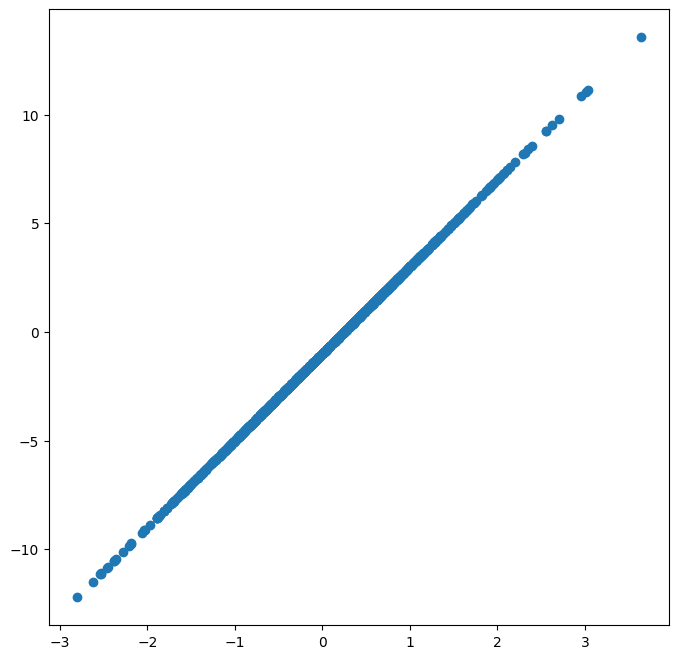

In [26]:
num_samples = 1000
# Pendefinisian fungsi yang sebenarnya (fungsi target) y = 4x - 1
true_w = 4.0
true_b = -1.0
# Menghasilkan data input (x-axis)
features = np.random.randn(num_samples)
# Menghasilkan data output (y-axis)
# Catatan: untuk kondisi multivariate -> np.dot(features, true_w) + true_b
labels = features * true_w + true_b # Formula tetap y = wx + b
# Visualisasi data
plt.figure(figsize=(8, 8))
plt.scatter(features, labels)
plt.show()

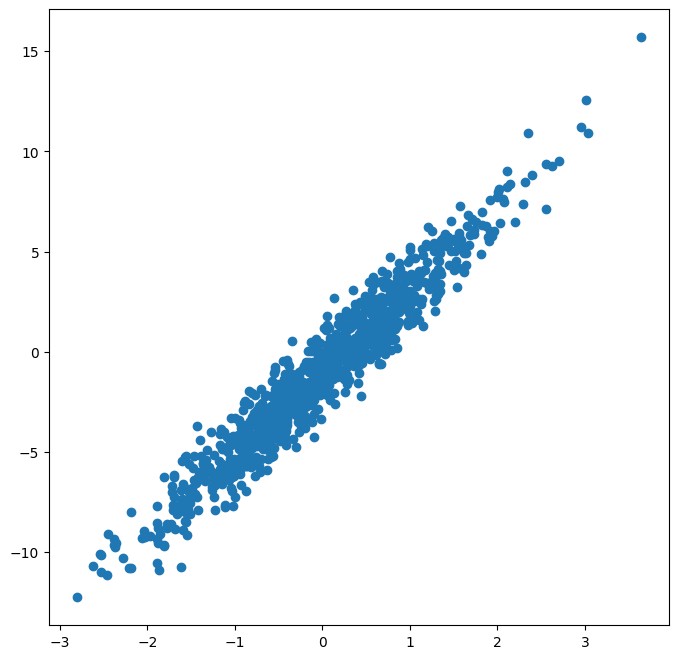

In [27]:
# Menambahkan noise pada sebaran data yang ada
labels += np.random.randn(num_samples)
# Visualisasi Data
plt.figure(figsize=(8, 8))
plt.scatter(features, labels)
plt.show()

# 1.2 Data Preparation
# Note :
###- Diambil 70% data sample untuk training, sisanya digunakan untuk Testing
###- Data diambil dengan menggunakan slicing dari features

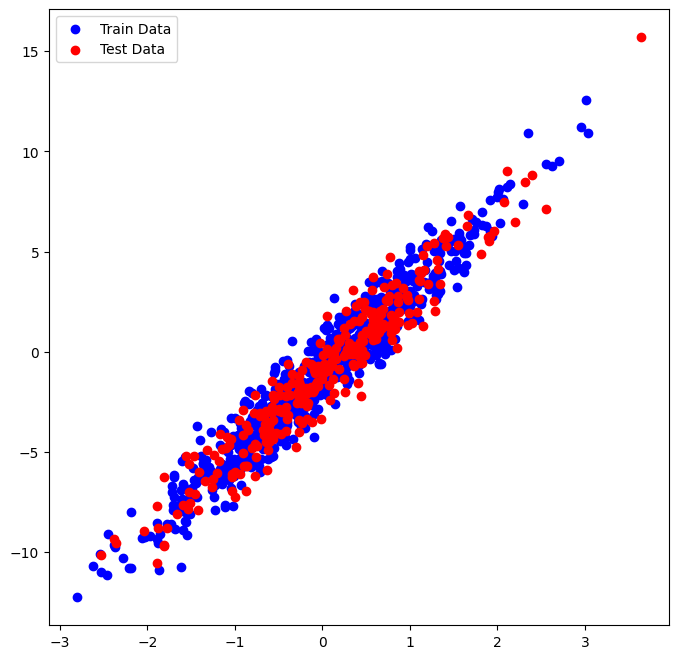

In [28]:
# Menentukan proporsi data training (70%)
train_size = 0.7
num_train = int(num_samples * train_size)
# Pembagian data ke training dan testing data
x_train = features[0:num_train]
y_train = labels[0:num_train]
x_test = features[num_train:num_samples]
y_test = labels[num_train:num_samples]
# Visualisasi Data
plt.figure(figsize=(8, 8))
plt.scatter(x_train, y_train, c='Blue', label='Train Data')
plt.scatter(x_test, y_test, c='Red', label='Test Data')
plt.legend()
plt.show()

#1.3. Function Definition
### Untuk meringankan resource komputasi digunakan batches, digunakan 80 data per batch. Untuk updating weight dan bias digunakan SGD sehingga setiap 1 data masuk dilakukan updating. Namun dipastikan semua data tersentuh.
### **Terdapat 5 fungsi yang didefinisikan:**  
####- Data-iter -> Fungsi yang membuat data menjadi batch saat training. data diambil perbatch dan diacak terlebih dahulu. Hal ini karena tidak terjadi perubahan signifikan saat data diolah secara mini-batch, stochastic, maupun full batch.digunakan
####- Linreg -> Hipotesa di linear regression
####- Squared loss -> menghitung loss dari fungsi dengan metode mse
####- SGD(Sochastic Gradient Descent) -> definisikan fungsi untuk menghitung loss dengan metode Stochastic


In [29]:

# Pendefinisian fungsi untuk membuat data terbagi dalam beberapa batch pada saat training
def data_iter(batch_size, features, labels):
  num_samples = features.shape[0]
  indices = list(range(num_samples))
  # Indeks diacak agar model tidak mempelajari urutan data
  random.shuffle(indices)
  for i in range(0, num_samples, batch_size):
    # Mengambil indeks untuk batch saat ini
    batch_indices = indices[i: min(i + batch_size, num_samples)]
    # NumPy menggunakan indexing array secara langsung
    yield features[batch_indices], labels[batch_indices]

# Pendefinisian fungsi untuk menghitung formula dari persamaan linier
def linreg(X, w, b):
  # Untuk kondisi multivariate gunakan np.dot(X, w) + b
  # Karena ini single variable (skalar), perkalian biasa sudah cukup
  return X * w + b

# Pendefinisian fungsi untuk perhitungan loss/error
def squared_loss(y_pred, y_act):
  # Formula dari L2 Loss = 0.5 * (y - y')^2
  return (y_pred - y_act.reshape(y_pred.shape)) ** 2 / 2

# Pendefinisian fungsi untuk proses update w dan b
def sgd(params, grads, lr, batch_size):
  # Melakukan pembaharuan nilai dari setiap parameter (w dan b)
  # params: list berisi [w, b]
  # grads: list berisi [dw, db] yang dihitung manual di loop training
  for param, grad in zip(params, grads):
    # Update rule: param = param - learning_rate * gradient
    # Kita bagi dengan batch_size untuk merata-ratakan gradien dalam satu batch
    param -= lr * grad / batch_size
    return params

In [30]:
# Contoh preprocessing batch
batch_size = 80
i = 0
for X, y in data_iter(batch_size, x_train, y_train):
  i += 1
  print(f"Ukuran x dalam batch ke-{i}:\n {X.shape}")
  print(f"Nilai x dalam batch ke-{i}:\n {X}")
  print(f"Nilai y dalam batch ke-{i}:\n {y}\n")

Ukuran x dalam batch ke-1:
 (80,)
Nilai x dalam batch ke-1:
 [-0.97156295 -0.93355103 -0.68699572  1.00741038 -0.289636   -1.2571762
 -0.08821161 -0.50822739  0.42644856 -1.43348323 -0.93576423  2.11090867
  0.12106907 -0.30866228 -1.69240968  1.07834106 -0.43423471  0.89456346
  0.34512794 -0.66610696  0.58992397 -0.09051776  0.8543971  -0.16464032
 -0.51730024  0.48008487  0.62217912 -1.15513409 -1.247391    0.16261758
  1.82436259 -1.43500361  1.50029887 -2.46668685  1.52478794 -0.82240594
  0.34032231 -0.80777686  2.02388999 -0.56468146 -1.64269558  0.44050732
  1.25803576  0.37688708  0.52447483 -1.60637977  0.71840213  1.62202048
 -1.06551174  1.56354548 -1.11256966 -1.5384061  -0.32680906  0.68236778
  1.35304632 -1.57789849 -1.14872464  0.67834625 -0.2612484  -0.68582364
  0.54254197  0.30965928  0.13959761  1.28053728 -0.15633407 -0.3044267
 -1.60176875  1.68533829  2.70050079 -0.11087245 -0.80556046  3.00918281
 -0.00912058 -0.27216537 -1.57047189  1.11570298 -0.48415797 -1.1

#1.4 Training model
###- Pada training digunakan hyperparameter sebagai berikut :
###- lr = 0.2, num_epochs = 100, net = linreg, loss = squared_loss, batch_size = 70
###- Pada awalnya ditentukan weight dan bias secara random
###- Selanjutnya output diprediksi dengan fungsi linreg
###- Error dihitung dengan menghitung perbedaan y prediksi dan y actual
###- dw dan db dihitung dengan chain rule turunan parsial
###- Weight dan bias kemudian diupdate dengan parameter sebelumnya
###- Hal ini diiterasi hingga jumlah batch sampai batch_size
###- Iterasi per batch dijalankan berkali-kali hingga jumlah epoch tercapai num_epoch

In [31]:
# Inisialisasi hyperparameter
lr = 0.2 # Learning rate
num_epochs = 100 # Jumlah dari iterasi
net = linreg # Linear regression model
loss = squared_loss # L2 loss
batch_size = 70 # Jumlah data pada setiap batch
# Melakukan inisialisasi dari parameter model w dan b
w = np.random.randn(1)
b = np.zeros(1)
print(f"Nilai Parameter Awal -> w={w}, b={b}")
# Proses pelatihan (training) model
for epoch in range(num_epochs):
  for X, y in data_iter(batch_size, x_train, y_train):
    # Memprediksi output
    y_pred = net(X, w, b)
    # Menghitung nilai gradient dari setiap parameter w dan b
    errors = (y_pred - y.reshape(y_pred.shape))
    dw = np.dot(X.T, errors)
    db = np.sum(errors)
    # Update SGD
    w, b = sgd([w, b], [dw, db], lr, batch_size)
  # Perhitungan loss/error setelah parameter diperbaharui untuk setiap epoch
  y_train_pred = linreg(x_train, w, b)
  train_l = squared_loss(y_train_pred, y_train)
  print(f"Epoch: {epoch + 1} - Loss: {train_l.mean():.6f} - w: {w} - b: {b}")

Nilai Parameter Awal -> w=[-0.39625302], b=[0.]
Epoch: 1 - Loss: 1.114754 - w: [3.53704928] - b: [0.]
Epoch: 2 - Loss: 0.985919 - w: [3.98050469] - b: [0.]
Epoch: 3 - Loss: 0.982864 - w: [4.07034933] - b: [0.]
Epoch: 4 - Loss: 0.983077 - w: [4.08390667] - b: [0.]
Epoch: 5 - Loss: 0.983043 - w: [4.08231491] - b: [0.]
Epoch: 6 - Loss: 0.982845 - w: [4.05348462] - b: [0.]
Epoch: 7 - Loss: 0.982820 - w: [4.0618509] - b: [0.]
Epoch: 8 - Loss: 0.982907 - w: [4.04729184] - b: [0.]
Epoch: 9 - Loss: 0.983594 - w: [4.10091884] - b: [0.]
Epoch: 10 - Loss: 0.983686 - w: [4.01834128] - b: [0.]
Epoch: 11 - Loss: 0.983683 - w: [4.01841428] - b: [0.]
Epoch: 12 - Loss: 0.985118 - w: [3.9916614] - b: [0.]
Epoch: 13 - Loss: 0.982986 - w: [4.04216186] - b: [0.]
Epoch: 14 - Loss: 0.983066 - w: [4.08342093] - b: [0.]
Epoch: 15 - Loss: 0.982892 - w: [4.07304056] - b: [0.]
Epoch: 16 - Loss: 0.983095 - w: [4.08471974] - b: [0.]
Epoch: 17 - Loss: 0.983185 - w: [4.08835138] - b: [0.]
Epoch: 18 - Loss: 0.983047 -

#1.5 Hasil Testing
### Testing dijalankan dengan melakukan inferensi pada fungsi hipotesa
### Selanjutnya grafik dibandingkan dengan data testing dan hipotesa, dan loss pada contour.

Final params - w: [4.06030327], b: [0.]
True params - w: 4.0, b: -1.0
Error Testing Data = 1.1212577060605626


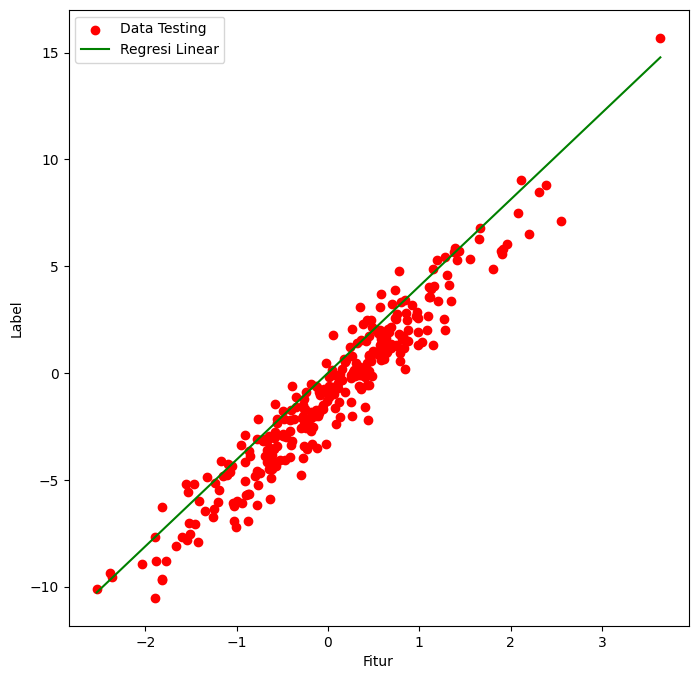

Text(0.5, 1.0, 'Tampilan Pergerakan Gradient Descent dalam Contour')

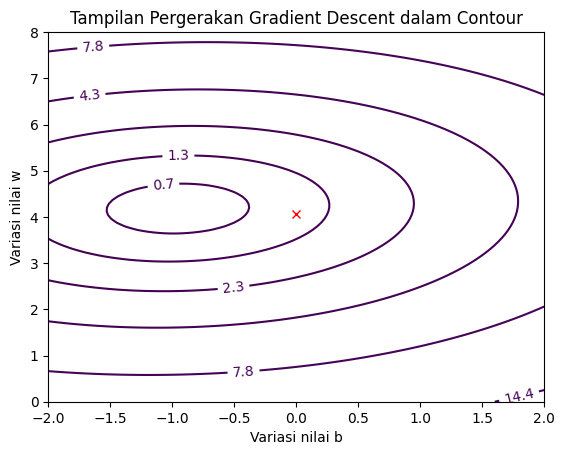

In [32]:
# Hasil Testing
# Evaluasi hasil pada data testing
print(f"Final params - w: {w}, b: {b}")
print(f"True params - w: {true_w}, b: {true_b}")
# Prediksi menggunakan data test
test_pred = net(x_test, w, b)
# Menghitung rata-rata error menggunakan fungsi loss yang sudah dibuat
errors = loss(test_pred, y_test).mean()
print(f"Error Testing Data = {errors}")

# Visualisasi data testing terhadap model
plt.figure(figsize=(8, 8))
plt.scatter(x_test, y_test, c='red', label='Data Testing')
# Menggambarkan garis dari hasil linear regression
X_line = np.linspace(x_test.min(), x_test.max(), 100)
y_line = net(X_line, w, b)
# Plot garis regresi
plt.plot(X_line, y_line, c='green', label='Regresi Linear')
plt.xlabel('Fitur')
plt.ylabel('Label')
plt.legend()
plt.show()

# Fungsi cost dari J(w) membentuk seperti mangkuk (bowl-shape) dan memiliki suatu nilai
# global minimum. Nilai minimum ini merupakan titik optimal untuk w dan b, serta
# setiap nilai gradient descent bergerak mendekat pada titik ini
b_vals = np.linspace(-2, 2, 100)
w_vals = np.linspace(0, 8, 100)
J_vals = np.zeros(shape=(len(b_vals), len(w_vals)))
# Proses perhitungan loss untuk setiap sebaran nilai w dan b
for i in range(0, len(b_vals)):
  for j in range(0, len(w_vals)):
    y_pred = net(X, w_vals[j], b_vals[i])
    loss = squared_loss(y_pred, y)
    J_vals[i,j] = loss.mean()
# Plotting nilai loss dari setiap sebaran nilai w dan b yang telah dihitung
# dalam visualisasi countour
ax = plt.contour(b_vals, w_vals, np.transpose(J_vals), levels=np.logspace(-2,3,20))
plt.plot(b[0], w[0], marker='x', color='r')
plt.clabel(ax, inline=1, fontsize=10)
plt.xlabel('Variasi nilai b')
plt.ylabel('Variasi nilai w')
plt.title('Tampilan Pergerakan Gradient Descent dalam Contour')


#1.6 Penggunaan Scikit learn untuk mengatasi masalah gradient descent

In [9]:
lin_reg = LinearRegression()
lin_reg.fit(x_train.reshape(-1,1), y_train.reshape(-1,1))
print(f"Nilai bobot b:\n{lin_reg.intercept_}\n\nNilai bobot w:\n{lin_reg.coef_}")

Nilai bobot b:
[-0.99866125]

Nilai bobot w:
[[4.00432114]]


#2 Pada multivariable
### Definisikan Dependencies

In [16]:
# Memuat library yang dibutuhkan untuk membangun pemrosesan data dan pembuatan
# model regresi linier multi variable dengan memanfaatkan fungsi yang ada
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
# Memasang Google Drive
from google.colab import drive
drive.mount("/content/drive")
# Pengaturan device
print("Using device: cpu (NumPy Standard)")

Mounted at /content/drive
Using device: cpu (NumPy Standard)


#2.1 Data Exploration
### Data difetch dari california housing dataset Scikit
### dilakukan printing deskripsi dari dataset
### **Mendeklarasikan variable pembantu berikut :**
### 1. data = berisi kumpulan data dari feature
### 2. target = berisi kumpulan data dari variable target
### 3. target_names = berisi kumpulan nama dari variable target
### 4. feature_names = berisi kumpulan nama dari feature

In [35]:
# Memuat dataset
housing = fetch_california_housing()
# Mengecek tipe dari dataset
print(type(housing))
# Mengecek informasi yang terdapat dalam dataset
# dictionary keys
print(housing.keys())
# Mencetak / menampilkan deskripsi dari dataset
print(housing['DESCR'])

# Catatan yang perlu diperhatikan:
# 1. data = berisi kumpulan data dari feature
# 2. target = berisi kumpulan data dari variable target
# 3. target_names = berisi kumpulan nama dari variable target
# 4. feature_names = berisi kumpulan nama dari feature
# Memuat kumpulan data feature ke dalam pandas DataFrame
housing_df = pd.DataFrame(data=housing['data'], columns=housing['feature_names'])
housing_df

# Menambahkan informasi varible target pada setiap baris data dalam DataFrame
target_name = housing['target_names'][0]
housing_df[target_name] = housing['target']
housing_df.head()

# Mengecek terhadap nilai yang kosong (missing values)
print(np.sum(np.isnan(housing_df)))

<class 'sklearn.utils._bunch.Bunch'>
dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])
.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in 

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


# 2.2 Feature correlation calculation
### Menghitung korelasi antar attribut
### Mengurutkan korelasi terbesar dan memplot correlation matrix dengan heatmap

Peringkat korelasi fitur terhadap target (Absolute):
MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
Latitude       0.144160
HouseAge       0.105623
AveBedrms      0.046701
Longitude      0.045967
Population     0.024650
AveOccup       0.023737
Name: MedHouseVal, dtype: float64


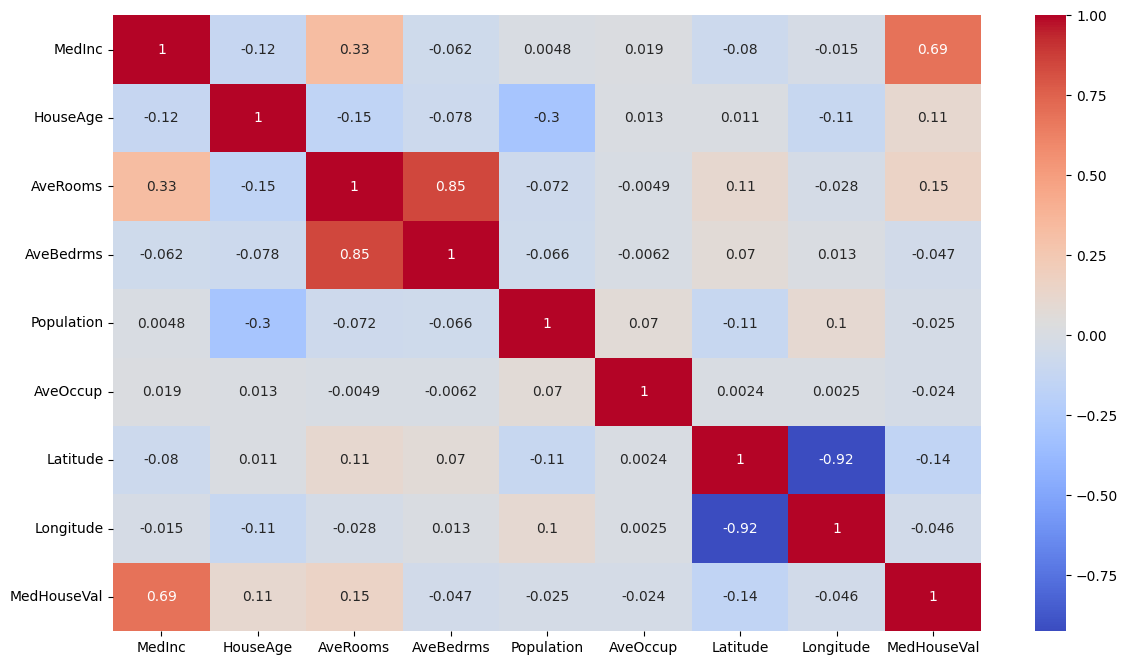

In [36]:
# Melakukan perhitungan feature correlation
# Menentukan ukuran gambar agar heatmap terbaca jelas
plt.figure(figsize=(14, 8))
# Menghitung matriks korelasi menggunakan metode Pearson secara default
corr = housing_df.corr()
# Menampilkan heatmap dengan anotasi angka korelasi
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2g")

# Negative correlation yang kuat sama bergunanya dengan positive correlation yang kuat.
# Sehingga perlu dilakukan sort terhadap nilai absolute-nya untuk melihat pengaruh fitur terhadap target.
# Kita fokus pada kolom 'MedHouseVal' sebagai variabel target.
correlation_ranking = abs(corr['MedHouseVal']).sort_values(ascending=False)
print("Peringkat korelasi fitur terhadap target (Absolute):")
print(correlation_ranking)

#2.3 Data Preparation
### deklarasi variable target dan atribute data
### dilakukan normalisasi dengan minmax scaler yaitu normalisasi data dengan mengurang data dengan data minimum dan membandingkannya dengan jangkauan data:
$$\frac{x - xmin}{xmax - xmin}$$



In [37]:
# y merupakan variable dependent, target variable (yang akan diestimasi oleh model kita)
y = housing_df['MedHouseVal']
# X merupakan features yang akan diberikan kepada model. iloc digunakan untuk
# melakukan slice pada DataFrame, dan diambil feature dengan corr yang baik dengan target
X = housing_df.loc[:, ('MedInc', 'AveRooms', 'Latitude', 'HouseAge')]
# Menampilkan ukuran dari setiap variabel X dan y
print(f"Data X = {X.shape}")
print(f"Data y = {y.shape}")

# Melakukan normalisasi data ke dalam rentang nilai data yang seragam
min_max_scaler = preprocessing.MinMaxScaler()
# Normalisasi Fitur X dan Y
X = min_max_scaler.fit_transform(X.values.reshape(-1, X.shape[1]))
y = min_max_scaler.fit_transform(y.values.reshape(-1, 1))
X = pd.DataFrame(X)
y = pd.DataFrame(y)
print(f"Contoh data X setelah normalisasi \n{X.head()}\n")
print(f"Contoh data y setelah normalisasi \n{y.head()}")

# Proses pembagian kumpulan data ke dalam data training dan testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
print(f"Shapes - X_train: {X_train.shape}, X_test: {X_test.shape}, y_train: {y_train.shape}, y_test: {y_test.shape}")

Data X = (20640, 4)
Data y = (20640,)
Contoh data X setelah normalisasi 
          0         1         2         3
0  0.539668  0.043512  0.567481  0.784314
1  0.538027  0.038224  0.565356  0.392157
2  0.466028  0.052756  0.564293  1.000000
3  0.354699  0.035241  0.564293  1.000000
4  0.230776  0.038534  0.564293  1.000000

Contoh data y setelah normalisasi 
          0
0  0.902266
1  0.708247
2  0.695051
3  0.672783
4  0.674638
Shapes - X_train: (14448, 4), X_test: (6192, 4), y_train: (14448, 1), y_test: (6192, 1)


#2.4 Model definition
### Pada model berikut dideklarasikan hipotesa sebagai objek dengan atribut weight dan bias
### dideklarasikan method forward untuk melakukan forward inference

### *comment: Walau lebih mudah dan standar disimpan pada pickle, penggunaan OOP seharusnya fungsi pembantu disimpan sebagai method. Selain itu untuk menghemat resource struktur data lebih baik disimpan dengan dictionary.


In [38]:

# Pembentukan class dari arsitektur model sebagai tujuan proses training menggunakan NumPy
class LinearRegressorNumPy:
  def __init__(self, n_features, n_outputs):
  # Inisialisasi bobot (weight) secara acak dan bias dengan nol
  # n_features: jumlah variabel input
  # n_outputs: jumlah variabel target
    self.w = np.random.randn(n_features, n_outputs) * 0.01
    self.b = np.zeros((1, n_outputs))
  def forward(self, x):
  # y = x * w + b (operasi perkalian matriks menggunakan np.dot atau @)
    return np.dot(x, self.w) + self.b
  # Beberapa catatan penting:
  # 1. n_features berisi jumlah total variabel dari fitur (dalam hal ini 4)
  # 2. n_outputs berisi jumlah variabel target (dalam hal ini 1)

  # Pengunaan arsitektur yang akan dilakukan pelatihan dan pengujian
n_features = X.shape[1] # Nilainya adalah 4
n_outputs = 1
# Membuat instance model (Tanpa parameter device)
model = LinearRegressorNumPy(n_features, n_outputs)
print(f"Model diinisialisasi dengan {n_features} fitur dan {n_outputs} output.")

# Menampilkan nilai dari semua trainable parameter (Weight dan Bias)
print("Weight (w): \n", model.w)
print("Bias (b): \n", model.b)

# Menampilkan rangkuman dari arsitektur yang digunakan
print(f"Input Shape : (Batch, {n_features})")
print(f"Weights Shape: {model.w.shape}")
print(f"Bias Shape : {model.b.shape}")

Model diinisialisasi dengan 4 fitur dan 1 output.
Weight (w): 
 [[-0.02182726]
 [ 0.0090597 ]
 [-0.01243228]
 [-0.01069671]]
Bias (b): 
 [[0.]]
Input Shape : (Batch, 4)
Weights Shape: (4, 1)
Bias Shape : (1, 1)


#2.5 Training Process
### Pada Training digunakan Hyperparameter sebagai berikut :
lr = 0.001, num_epochs = 200, batch_size = 256
### Selanjutnya DF diconversikan ke array NumPy
### Sampling batches dilakukan dengan dungsi data_iter
### Kemudian dilakukan looping per epoch
### Selanjutnya dihitung gradien dari weight dan bias
### Selanjutnya dilakukan backprop per batchsize dengan menggunakan SGD



In [39]:
# Inisialisasi beberapa parameter dan fungsi untuk mendukung proses training
lr = 0.001
num_epochs = 200
batch_size = 256

# Konversi DataFrame ke dalam array NumPy
# Pastikan data dalam tipe float32 untuk konsistensi
X_train_np = X_train.values.astype(np.float32)
y_train_np = y_train.values.astype(np.float32)
X_test_np = X_test.values.astype(np.float32)
y_test_np = y_test.values.astype(np.float32)
# Sampling batches akan dilakukan langsung menggunakan fungsi data_iter yang sudah dibuat

# Proses pelatihan (training)
for epoch in range(num_epochs):
# Menggunakan data_iter manual untuk sampling batch
  for input_batch, target_batch in data_iter(batch_size, X_train_np, y_train_np):
    # 1. Forward Pass: Model memberikan luaran regresi
    output = model.forward(input_batch)
    # 2. Perhitungan Error
    error = output - target_batch.reshape(output.shape)
    # 3. Menghitung gradien secara manual (Backpropagation manual)
    # dw = (1/m) * dot(X^T * error)
    # db = (1/m) * sum(error)
    m = input_batch.shape[0]
    dw = np.dot(input_batch.T, error)
    db = np.sum(error, axis=0, keepdims=True)
    # 4. Memperbaharui parameter menggunakan SGD manual
    # Update: param = param - lr * (grad / batch_size)
    model.w, model.b = sgd([model.w, model.b], [dw, db], lr, m)
  print(f"[Epoch {epoch + 1}] Training loss: {epoch_loss:.6f}")
# Menghitung total loss untuk monitoring (setelah satu epoch)
final_output = model.forward(X_train_np)
epoch_loss = squared_loss(final_output, y_train_np).mean()
print(f"[Epoch {epoch + 1}] Training loss: {epoch_loss:.6f}")

[Epoch 1] Training loss: 0.024095
[Epoch 2] Training loss: 0.024095
[Epoch 3] Training loss: 0.024095
[Epoch 4] Training loss: 0.024095
[Epoch 5] Training loss: 0.024095
[Epoch 6] Training loss: 0.024095
[Epoch 7] Training loss: 0.024095
[Epoch 8] Training loss: 0.024095
[Epoch 9] Training loss: 0.024095
[Epoch 10] Training loss: 0.024095
[Epoch 11] Training loss: 0.024095
[Epoch 12] Training loss: 0.024095
[Epoch 13] Training loss: 0.024095
[Epoch 14] Training loss: 0.024095
[Epoch 15] Training loss: 0.024095
[Epoch 16] Training loss: 0.024095
[Epoch 17] Training loss: 0.024095
[Epoch 18] Training loss: 0.024095
[Epoch 19] Training loss: 0.024095
[Epoch 20] Training loss: 0.024095
[Epoch 21] Training loss: 0.024095
[Epoch 22] Training loss: 0.024095
[Epoch 23] Training loss: 0.024095
[Epoch 24] Training loss: 0.024095
[Epoch 25] Training loss: 0.024095
[Epoch 26] Training loss: 0.024095
[Epoch 27] Training loss: 0.024095
[Epoch 28] Training loss: 0.024095
[Epoch 29] Training loss: 0.0

#2.6 Testing Process
### Dilakukan testing dengan menyimpan data-data loss sebagai sebuah stack
### Data prediksi kemudian diprediksi dan diplot dan dibandingkan dengan data aktual

Mean test loss = 0.02425975022040514
Nilai dari bobot(w): 
[[0.43530049]
 [0.04970064]
 [0.15527656]
 [0.40016582]]

Nilai dari bias(b): 
[[0.]]


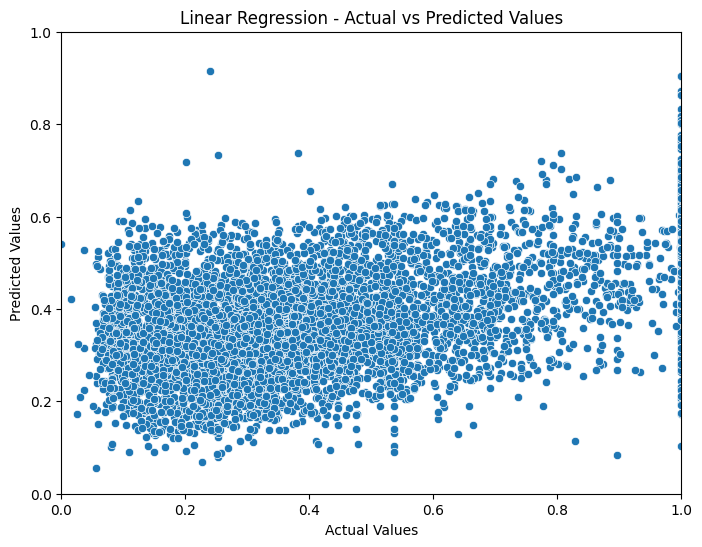

In [40]:
# Mengatur mode testing
test_losses = []
# Melakukan prediksi pada seluruh data test sekaligus
# X_test_np dan y_test_np adalah array NumPy yang sudah disiapkan di tahap 2.5
output = model.forward(X_test_np)
loss_value = squared_loss(output, y_test_np)
test_losses.append(loss_value.mean())
print(f"Mean test loss = {np.mean(test_losses)}")

# Menampilkan nilai akhir parameter setelah training
print(f"Nilai dari bobot(w): \n{model.w}\n")
print(f"Nilai dari bias(b): \n{model.b}")

# Membuat prediksi menggunakan model yang telah dilatih
predicted_values = model.forward(X_test_np)
# Jika diperlukan untuk visualisasi, pastikan dimensinya sesuai
predicted_values = predicted_values.reshape(-1, 1)

# Melakukan scatter plot dari actual vs predicted values
plt.figure(figsize=(8, 6))
plt.xlim(0.0, 1.0)
plt.ylim(0.0, 1.0)
# y_test_np adalah nilai asli, predicted_values adalah hasil model
sns.scatterplot(x=y_test_np.flatten(), y=predicted_values.flatten())
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Linear Regression - Actual vs Predicted Values')
plt.show()

#2.7 Dumping Weight dan Bias sebagai Pickle

In [46]:
import pickle # Library untuk menyimpan objek Python/NumPy
# 1. Membuat direktori models
# Sesuaikan path dengan struktur folder di Google Drive Anda
MODEL_PATH = "/content/drive/MyDrive/Dokumentasi Kuliah (Asisten)/Dasar Sistem dan Kendali Cerdas - 2026/Numpy ver/Mod"
if not os.path.exists(MODEL_PATH):
  os.makedirs(MODEL_PATH)
# 2. Membuat model save path
# Kita gunakan ekstensi .pkl untuk file NumPy/Pickle
MODEL_NAME = "02_numpy_multivariate_linear_regression.pkl"
MODEL_SAVE_PATH = os.path.join(MODEL_PATH, MODEL_NAME)
# 3. Menyimpan objek model NumPy
print(f"Saving model to: {MODEL_SAVE_PATH}")
# Menggunakan pickle untuk menyimpan seluruh objek 'model'
with open(MODEL_SAVE_PATH, 'wb') as f:
  pickle.dump(model, f)
# 4. Memuat/Load model yang tersedia
if os.path.exists(MODEL_SAVE_PATH):
  with open(MODEL_SAVE_PATH, 'rb') as f:
    loaded_model = pickle.load(f)
    print("Model berhasil dimuat!")
    print(f"Bobot model yang dimuat: \n{loaded_model.w}\n{loaded_model.b}")
else:
  print("File model tidak ditemukan.")

Saving model to: /content/drive/MyDrive/Dokumentasi Kuliah (Asisten)/Dasar Sistem dan Kendali Cerdas - 2026/Numpy ver/Mod/02_numpy_multivariate_linear_regression.pkl
Model berhasil dimuat!
Bobot model yang dimuat: 
[[0.43530049]
 [0.04970064]
 [0.15527656]
 [0.40016582]]
[[0.]]


#2.8 Implementasi menggunakan Scikit learn

In [47]:
multivariate_lin_reg = LinearRegression()
multivariate_lin_reg.fit(X_train_np, y_train_np)
print(f"Nilai bobot b:\n{multivariate_lin_reg.intercept_}\n\nNilai bobot w:\n{multivariate_lin_reg.coef_}")

Nilai bobot b:
[0.04814246]

Nilai bobot w:
[[ 1.3351641  -0.95902413 -0.08212632  0.17625862]]
